# Skin Cancer Classification — EDA & Preprocessing




## 1. Setup


In [4]:
import os
import glob
from pathlib import Path
DATASET_DIR = "Skin Cancer Detection"   # folder next to this notebook (train/valid/test)
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)




## 2. Data Loading


In [5]:
records = []
for path in glob.glob(os.path.join(DATASET_DIR, "**", "*"), recursive=True):
    p = Path(path)
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
        split = next((s for s in ["train", "valid", "test"] if s in p.parts), "unknown")
        records.append({"filepath": str(p), "label": p.parent.name, "split": split})

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()


Total images: 16831


,filepath,label,split
0,Skin Cancer Detection\test\akiec\ISIC_0024562_...,akiec,test
1,Skin Cancer Detection\test\akiec\ISIC_0024646_...,akiec,test
2,Skin Cancer Detection\test\akiec\ISIC_0025247_...,akiec,test
3,Skin Cancer Detection\test\akiec\ISIC_0025539_...,akiec,test
4,Skin Cancer Detection\test\akiec\ISIC_0025637_...,akiec,test


## 3. Data Cleaning


In [6]:
import hashlib

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return os.path.getsize(path) > 0
    except Exception:
        return False

df["is_valid"] = df["filepath"].apply(is_valid_image)
n_corrupt = (~df["is_valid"]).sum()
print(f"Corrupted/unreadable files: {n_corrupt}")

df = df[df["is_valid"]].drop(columns=["is_valid"]).reset_index(drop=True)

# Duplicate check via MD5 hash of file bytes
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["hash"] = df["filepath"].apply(file_hash)
n_dupes = df["hash"].duplicated().sum()
print(f"Duplicate images: {n_dupes}")

df = df.drop_duplicates(subset="hash").drop(columns=["hash"]).reset_index(drop=True)
print("Clean dataset size:", len(df))


Corrupted/unreadable files: 0
Duplicate images: 1
Clean dataset size: 16830


## 4. Exploratory Data Analysis

### 4.1 Class distribution
Bar chart and an indexed pie chart, both using a clear, distinct color palette so all 7 classes are easy to tell apart.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14940\2116928004.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette, ax=axes[0])


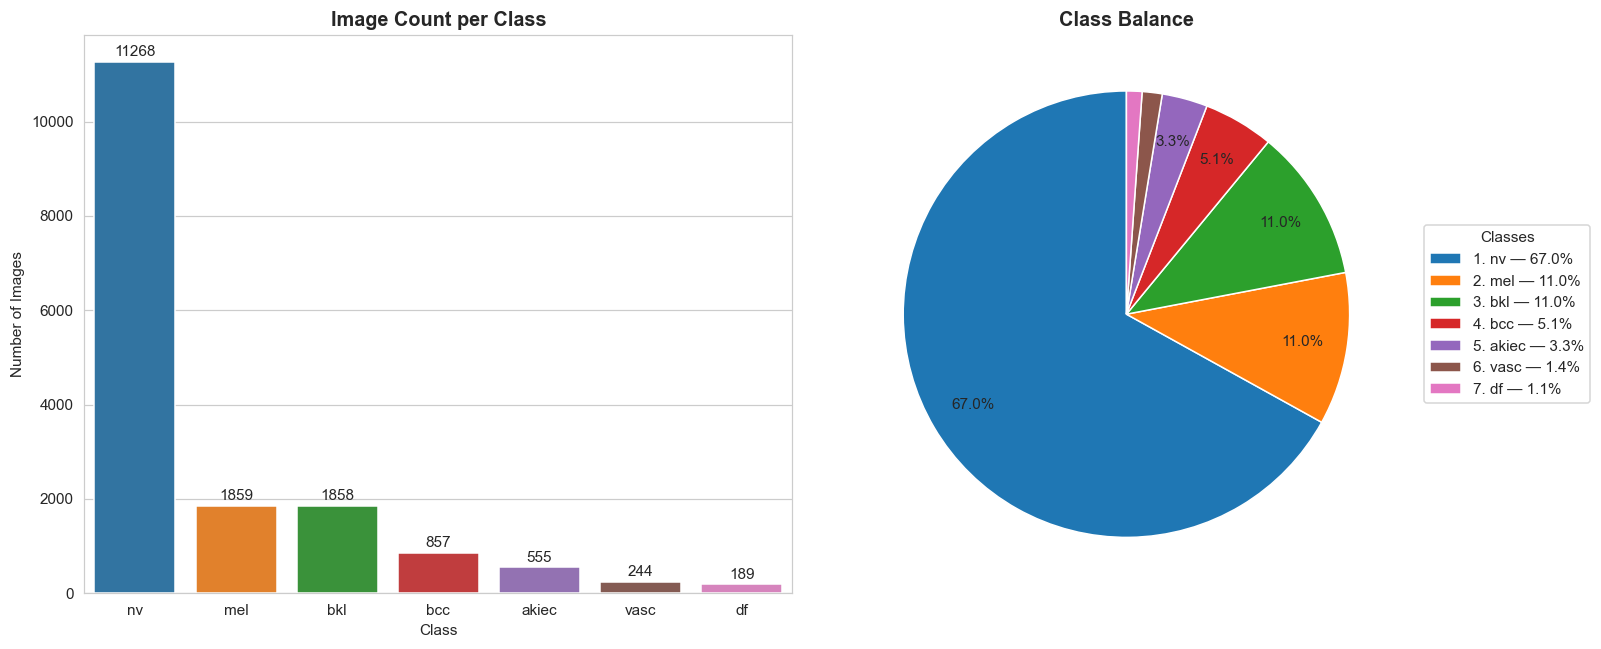

In [7]:
class_counts = df["label"].value_counts()
palette = sns.color_palette("tab10", n_colors=len(class_counts))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette, ax=axes[0])
axes[0].set_title("Image Count per Class", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + max(class_counts.values) * 0.01, str(v), ha="center", fontsize=10)

# Indexed pie chart
labels_idx = [f"{i+1}. {lbl}" for i, lbl in enumerate(class_counts.index)]
percentages = class_counts.values / class_counts.values.sum() * 100
autopct_fn = lambda pct: f"{pct:.1f}%" if pct >= 3 else ""
wedges, _, _ = axes[1].pie(class_counts.values, autopct=autopct_fn, startangle=90,
                            colors=palette, pctdistance=0.8, textprops={"fontsize": 10})
legend_labels = [f"{i+1}. {lbl} — {pct:.1f}%" for i, (lbl, pct) in enumerate(zip(class_counts.index, percentages))]
axes[1].legend(wedges, legend_labels, title="Classes", loc="center left",
               bbox_to_anchor=(1.02, 0.5), fontsize=10)
axes[1].set_title("Class Balance", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


### 4.2 Train / Valid / Test split per class
A stacked bar chart showing how each class is distributed across the three splits — confirms the splits are proportionate and no class is missing from any split.

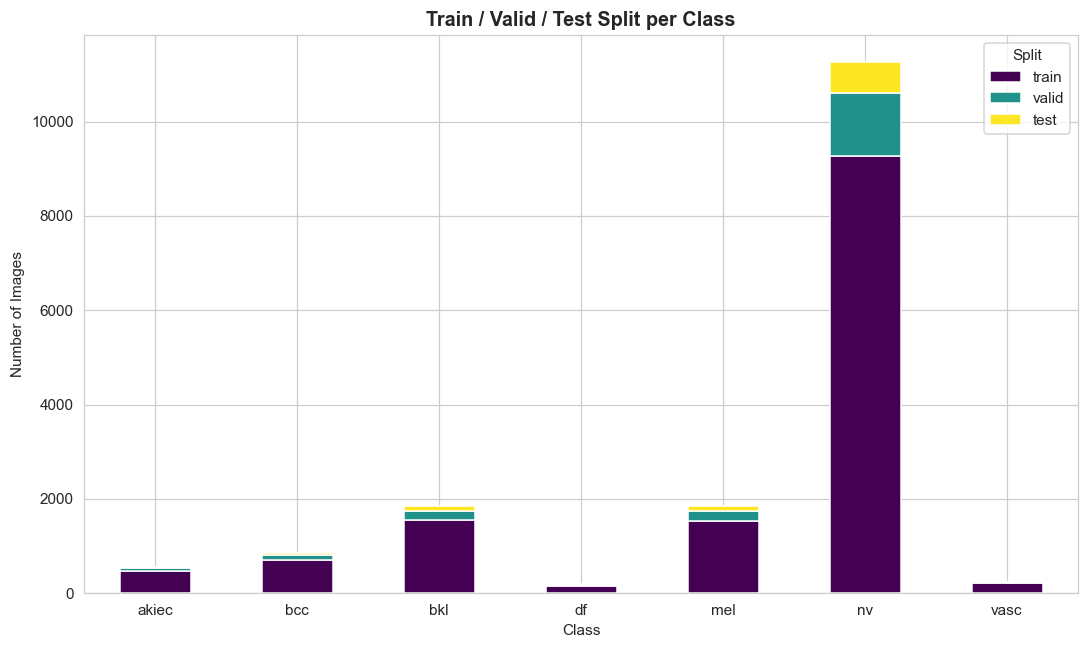

split,train,valid,test
label,,,
akiec,468,59,28
bcc,698,105,54
bkl,1545,202,111
df,148,30,11
mel,1522,226,111
nv,9274,1326,668
vasc,206,30,8


In [8]:
split_counts = df.groupby(["label", "split"]).size().unstack(fill_value=0)
split_counts = split_counts[["train", "valid", "test"]] if set(["train","valid","test"]).issubset(split_counts.columns) else split_counts

split_counts.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Train / Valid / Test Split per Class", fontsize=13, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Split")
plt.tight_layout()
plt.show()

split_counts


### 4.3 Sample images per class
Display a few sample lesion images from each class in a grid, to visually confirm the labels look correct and see how the classes differ in appearance.

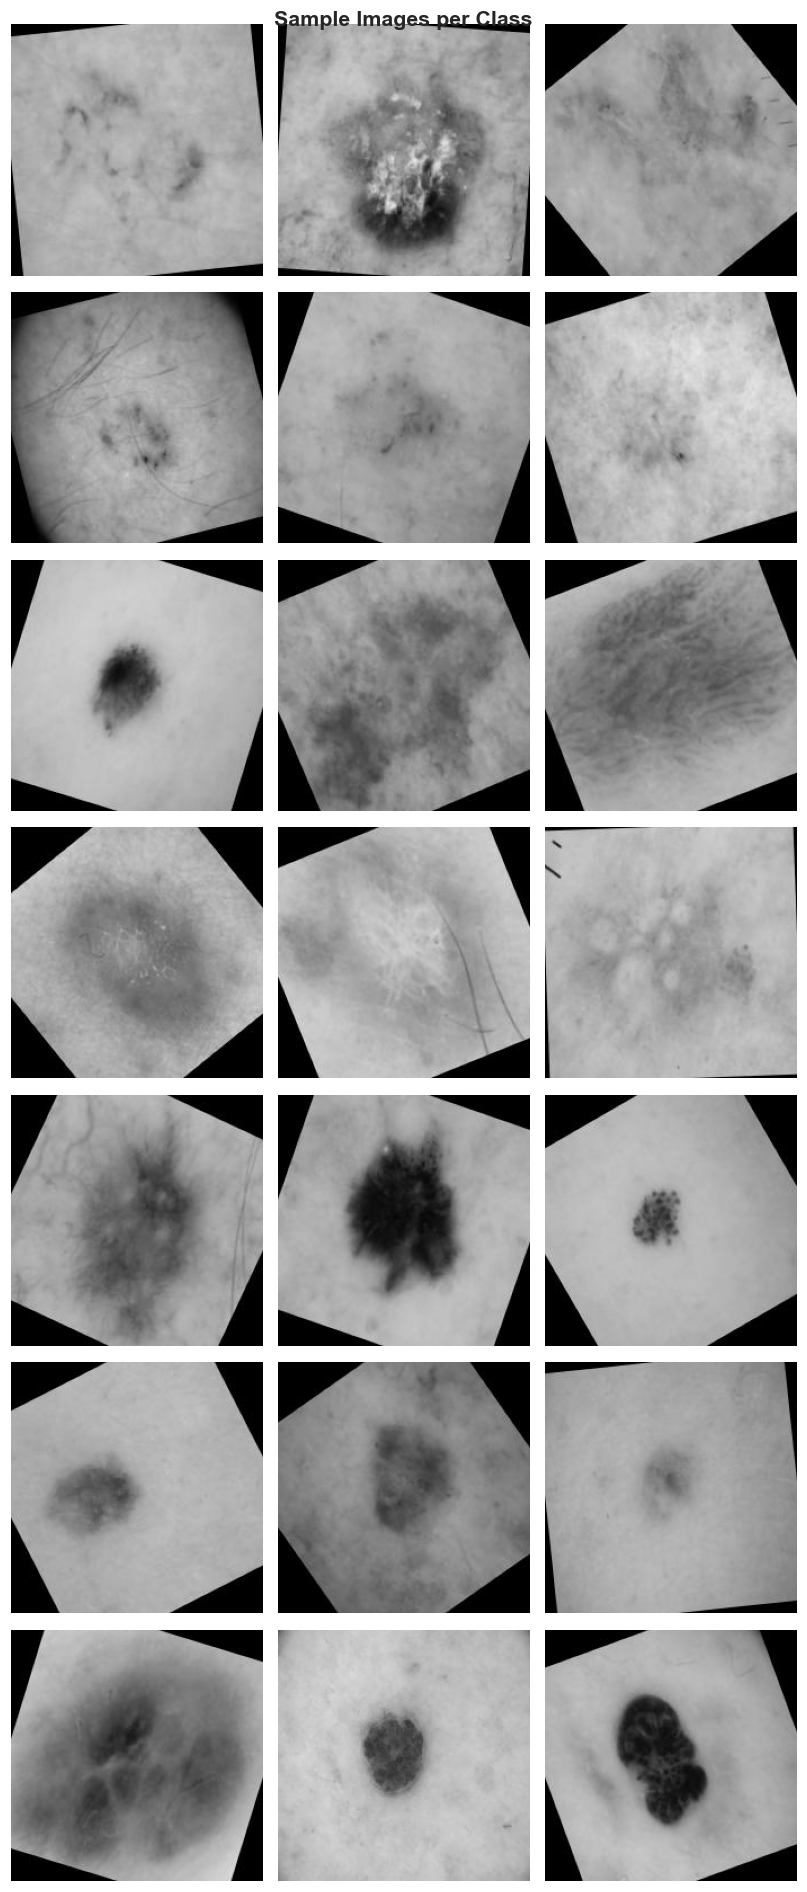

In [9]:
classes = sorted(df["label"].unique())
n_samples = 3

fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.5, len(classes) * 2.5))
for i, cls in enumerate(classes):
    paths = df[df["label"] == cls]["filepath"].sample(n=min(n_samples, (df["label"] == cls).sum()), random_state=1)
    for j, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(cls, fontsize=11, rotation=0, labelpad=40, va="center")

plt.suptitle("Sample Images per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



### 4.4 Image dimensions
Sample a subset of images and check their width/height, to see whether resizing is needed before feeding images into a model.

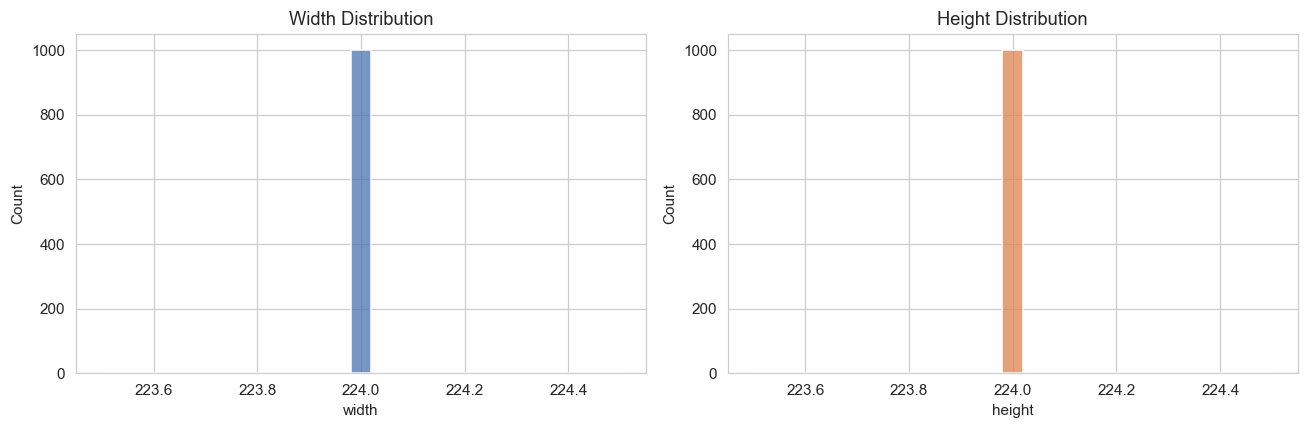

,width,height
count,1000.0,1000.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


In [10]:
sample_df = df.sample(n=min(1000, len(df)), random_state=42).copy()
sizes = sample_df["filepath"].apply(lambda p: Image.open(p).size)
sample_df["width"] = sizes.apply(lambda s: s[0])
sample_df["height"] = sizes.apply(lambda s: s[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sample_df["width"], bins=25, color="#4C72B0", ax=axes[0])
axes[0].set_title("Width Distribution")
sns.histplot(sample_df["height"], bins=25, color="#DD8452", ax=axes[1])
axes[1].set_title("Height Distribution")
plt.tight_layout()
plt.show()

sample_df[["width", "height"]].describe()


### 4.5 Average color per class
Compute the mean RGB intensity per class to see if color alone shows any visible difference between lesion types — useful context since color is a diagnostic cue for skin lesions.

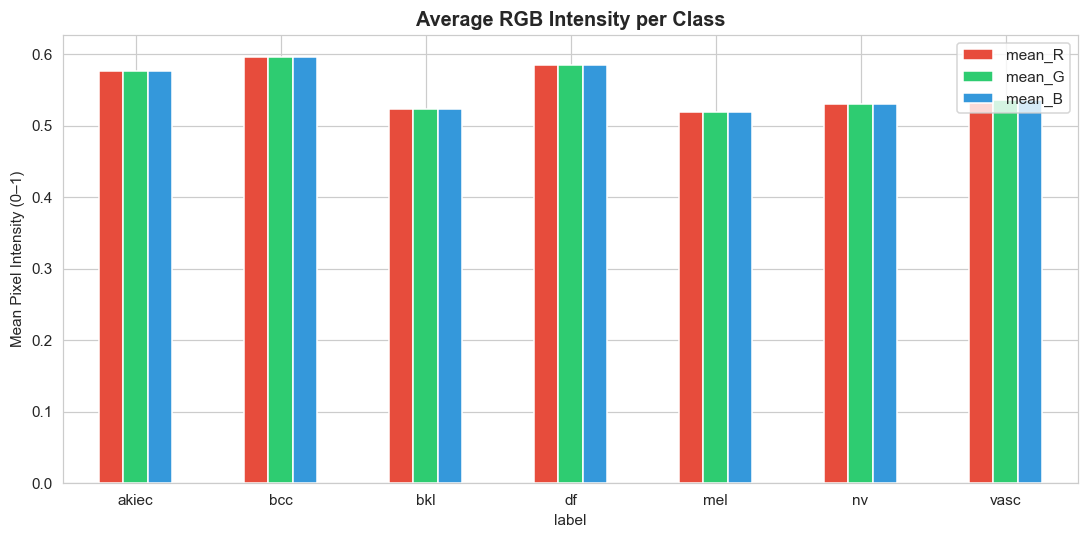

In [11]:
def mean_rgb(path, size=(64, 64)):
    arr = np.array(Image.open(path).convert("RGB").resize(size)) / 255.0
    return arr.reshape(-1, 3).mean(axis=0)

sample_df[["mean_R", "mean_G", "mean_B"]] = pd.DataFrame(
    sample_df["filepath"].apply(mean_rgb).tolist(), index=sample_df.index)

class_rgb = sample_df.groupby("label")[["mean_R", "mean_G", "mean_B"]].mean()

class_rgb.plot(kind="bar", figsize=(10, 5), color=["#E74C3C", "#2ECC71", "#3498DB"])
plt.title("Average RGB Intensity per Class", fontsize=13, fontweight="bold")
plt.ylabel("Mean Pixel Intensity (0–1)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Data Preprocessing


In [12]:
IMG_SIZE = (128, 128)

def load_and_preprocess(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img / 255.0          # normalize to [0, 1]
    return img

# Quick check on one image
sample_img = load_and_preprocess(df["filepath"].iloc[0])
print("Preprocessed image shape:", sample_img.shape, "| value range:", sample_img.min(), "-", sample_img.max())

# Class weights to handle imbalance (inverse frequency)
class_counts_all = df["label"].value_counts()
total = len(df)
class_weights = {cls: total / (len(class_counts_all) * count) for cls, count in class_counts_all.items()}
pd.Series(class_weights, name="class_weight").sort_values(ascending=False)


Preprocessed image shape: (128, 128, 3) | value range: 0.14901960784313725 - 0.8313725490196079


df       12.721088
vasc      9.853630
akiec     4.332046
bcc       2.805468
bkl       1.294018
mel       1.293322
nv        0.213373
Name: class_weight, dtype: float64

## 6. Neural Network (CNN) Implementation

Skin lesion classification is an image task, so a **Convolutional Neural Network (CNN)** is used rather than a classifier built on hand-crafted features. This section:

1. Builds `tf.data`/`ImageDataGenerator` pipelines from the `df` produced during EDA (train / valid / test splits, image resizing, normalization, augmentation).
2. Defines a configurable CNN architecture.
3. Trains a **baseline** model.
4. Runs a small **hyperparameter search** (learning rate, dropout, optimizer, batch size) and compares validation performance.
5. Trains a **final** model with the best configuration found.
6. Evaluates it with a **confusion matrix**, **precision**, **recall**, and **F1-score**.

> **Note:** This section assumes TensorFlow/Keras is installed (`pip install tensorflow`) and that the `Skin Cancer Detection` dataset folder used in the EDA section above is available at `DATASET_DIR`.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support, accuracy_score)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)


### 6.1 Data Generators

We reuse the cleaned `df` (filepath, label, split) from the EDA section. `ImageDataGenerator` handles resizing, pixel normalization, and (for the training set only) light augmentation appropriate for dermoscopic images — small rotations/flips/zoom, without heavy color distortion since color is a diagnostic cue (see Section 4.5).

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (128, 128)     # keep consistent with Section 5 preprocessing
BATCH_SIZE = 32
NUM_CLASSES = df["label"].nunique()
CLASS_NAMES = sorted(df["label"].unique())
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

train_df = df[df["split"] == "train"].reset_index(drop=True)
valid_df = df[df["split"] == "valid"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)
print("Train:", len(train_df), "| Valid:", len(valid_df), "| Test:", len(test_df))

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,        # lesions have no canonical orientation
)
eval_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, dataframe, shuffle):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        class_mode="categorical",
        classes=CLASS_NAMES,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42,
    )

train_gen = make_generator(train_datagen, train_df, shuffle=True)
valid_gen = make_generator(eval_datagen, valid_df, shuffle=False)
test_gen  = make_generator(eval_datagen, test_df,  shuffle=False)


### 6.2 CNN Architecture

A compact CNN with three convolutional blocks (Conv2D → BatchNorm → ReLU → MaxPool), global average pooling, and a dense classification head. Architecture parameters (filters, dropout rate, dense units) and optimization parameters (optimizer, learning rate) are exposed as function arguments so they can be swept during hyperparameter tuning in Section 7.

In [ ]:
def build_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES,
              conv_filters=(32, 64, 128), dense_units=128,
              dropout_rate=0.4, learning_rate=1e-3, optimizer_name="adam"):
    """Builds and compiles a configurable CNN classifier."""
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters in conv_filters:
        x = layers.Conv2D(filters, (3, 3), padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    if optimizer_name == "adam":
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        opt = optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(optimizer=opt, loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

baseline_model = build_cnn()
baseline_model.summary()


### 6.3 Baseline Training

The baseline model uses default hyperparameters (Adam, lr=1e-3, dropout=0.4, batch size 32). `class_weight` (computed in Section 5) compensates for class imbalance. `EarlyStopping` and `ReduceLROnPlateau` are used so training stops/adapts automatically rather than relying on a fixed, possibly wasteful, epoch count.

In [ ]:
EPOCHS = 25

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=cb,
)


### 6.4 Baseline Training Curves

In [ ]:
def plot_history(history, title="Training History"):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="valid")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="valid")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN")


## 7. Hyperparameter Tuning

Several configurations are compared by varying:
- **Learning rate**: `1e-3` vs `1e-4`
- **Optimizer**: `adam` vs `rmsprop`
- **Dropout rate**: `0.3` vs `0.5`
- **Batch size**: `32` vs `64`

Each configuration is trained for a shorter, fixed number of epochs (with early stopping) purely to *compare relative behaviour* — the winning configuration is then retrained for longer in Section 8 to produce the final model.

In [ ]:
experiment_configs = [
    {"name": "baseline (lr=1e-3, adam, drop=0.4, bs=32)",
     "learning_rate": 1e-3, "optimizer_name": "adam", "dropout_rate": 0.4, "batch_size": 32},
    {"name": "lower lr (lr=1e-4, adam, drop=0.4, bs=32)",
     "learning_rate": 1e-4, "optimizer_name": "adam", "dropout_rate": 0.4, "batch_size": 32},
    {"name": "rmsprop (lr=1e-3, rmsprop, drop=0.4, bs=32)",
     "learning_rate": 1e-3, "optimizer_name": "rmsprop", "dropout_rate": 0.4, "batch_size": 32},
    {"name": "more dropout (lr=1e-3, adam, drop=0.5, bs=32)",
     "learning_rate": 1e-3, "optimizer_name": "adam", "dropout_rate": 0.5, "batch_size": 32},
    {"name": "larger batch (lr=1e-3, adam, drop=0.4, bs=64)",
     "learning_rate": 1e-3, "optimizer_name": "adam", "dropout_rate": 0.4, "batch_size": 64},
]

TUNE_EPOCHS = 10
tune_cb = [callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

results = []
histories = {}

for cfg in experiment_configs:
    print("=" * 70)
    print("Training:", cfg["name"])
    print("=" * 70)

    bs = cfg["batch_size"]
    tg = make_generator(train_datagen, train_df, shuffle=True)
    tg.batch_size = bs
    vg = make_generator(eval_datagen, valid_df, shuffle=False)
    vg.batch_size = bs

    model = build_cnn(learning_rate=cfg["learning_rate"],
                       optimizer_name=cfg["optimizer_name"],
                       dropout_rate=cfg["dropout_rate"])

    hist = model.fit(tg, validation_data=vg, epochs=TUNE_EPOCHS,
                      class_weight=class_weights, callbacks=tune_cb, verbose=1)

    best_val_acc = max(hist.history["val_accuracy"])
    best_val_loss = min(hist.history["val_loss"])
    results.append({"config": cfg["name"], "best_val_accuracy": best_val_acc,
                     "best_val_loss": best_val_loss})
    histories[cfg["name"]] = hist

results_df = pd.DataFrame(results).sort_values("best_val_accuracy", ascending=False)
results_df


### 7.1 Comparing Configurations

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, x="best_val_accuracy", y="config",
            palette="viridis", ax=axes[0])
axes[0].set_title("Best Validation Accuracy per Configuration")
axes[0].set_xlabel("Validation Accuracy"); axes[0].set_ylabel("")

sns.barplot(data=results_df, x="best_val_loss", y="config",
            palette="magma", ax=axes[1])
axes[1].set_title("Best Validation Loss per Configuration")
axes[1].set_xlabel("Validation Loss"); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

best_cfg_name = results_df.iloc[0]["config"]
best_cfg = next(c for c in experiment_configs if c["name"] == best_cfg_name)
print("Best configuration:", best_cfg)


## 8. Final Model Training

The best-performing configuration from Section 7 is retrained for more epochs (with early stopping and LR reduction) to produce the final model used for evaluation.

In [ ]:
final_train_gen = make_generator(train_datagen, train_df, shuffle=True)
final_train_gen.batch_size = best_cfg["batch_size"]
final_valid_gen = make_generator(eval_datagen, valid_df, shuffle=False)
final_valid_gen.batch_size = best_cfg["batch_size"]
final_test_gen  = make_generator(eval_datagen, test_df, shuffle=False)
final_test_gen.batch_size = best_cfg["batch_size"]

final_model = build_cnn(learning_rate=best_cfg["learning_rate"],
                         optimizer_name=best_cfg["optimizer_name"],
                         dropout_rate=best_cfg["dropout_rate"])

final_cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    callbacks.ModelCheckpoint("best_skin_cancer_cnn.h5", monitor="val_accuracy",
                               save_best_only=True),
]

history_final = final_model.fit(
    final_train_gen,
    validation_data=final_valid_gen,
    epochs=30,
    class_weight=class_weights,
    callbacks=final_cb,
)

plot_history(history_final, "Final CNN")


## 9. Evaluation on Test Set

The final model is evaluated on the **held-out test split** using:
- **Confusion matrix** — per-class breakdown of correct vs. misclassified predictions.
- **Precision, Recall, F1-score** — per class and averaged (macro / weighted), which matter more than raw accuracy given the class imbalance shown in Section 4.1.

In [ ]:
final_test_gen.reset()
y_true = final_test_gen.classes
pred_probs = final_model.predict(final_test_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")


### 9.1 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (Row-Normalized)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 9.2 Precision, Recall, F1-Score

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                     output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df


In [ ]:
per_class = report_df.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]

per_class.plot(kind="bar", figsize=(11, 5), colormap="Set2")
plt.title("Precision / Recall / F1-Score per Class", fontsize=13, fontweight="bold")
plt.ylabel("Score"); plt.xlabel("Class")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


### 9.3 Misclassified Examples

Inspecting a handful of misclassified test images gives qualitative insight into where the model struggles (e.g. visually similar lesion types).

In [ ]:
mis_idx = np.where(y_true != y_pred)[0]
n_show = min(8, len(mis_idx))
show_idx = np.random.RandomState(42).choice(mis_idx, size=n_show, replace=False) if n_show else []

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for ax, idx in zip(axes, show_idx):
    filepath = test_df.iloc[idx]["filepath"]
    img = Image.open(filepath).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}",
                 fontsize=9, color="crimson")
    ax.axis("off")
for ax in axes[len(show_idx):]:
    ax.axis("off")

plt.suptitle("Sample Misclassified Test Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Discussion & Findings

*(Fill in with the actual numbers once the notebook has been run end-to-end on your machine/environment — the cells above will populate `results_df`, `report_df`, `test_accuracy`, and the confusion matrix figures used as the evidence for this section.)*

**Model & training setup**
- Architecture: 3-block CNN (Conv → BatchNorm → ReLU → MaxPool) + GAP + Dense(128) + Dropout + Softmax.
- Input size: 128×128×3, pixel values normalized to [0, 1].
- Class imbalance handled via inverse-frequency `class_weight`.
- Regularization: BatchNorm, Dropout, data augmentation (rotation/shift/zoom/flip), early stopping.

**Hyperparameter tuning observations**
- Report which configuration in `results_df` achieved the best validation accuracy/loss, and discuss the effect of each hyperparameter individually, e.g.:
  - Effect of learning rate (1e-3 vs 1e-4) on convergence speed and stability.
  - Adam vs RMSprop convergence behaviour.
  - Effect of dropout rate on the train/validation accuracy gap (overfitting indicator).
  - Effect of batch size on training stability and epoch time.

**Test set performance**
- Overall test accuracy: `test_accuracy`.
- Per-class precision/recall/F1 from `report_df` — call out which classes are hardest to classify (usually the minority classes / visually similar lesion types) and relate this back to the class-imbalance and average-color findings from the EDA section.
- Confusion matrix patterns — which pairs of classes get confused most often, and a possible clinical/visual explanation (e.g. similar coloration or texture, as seen in Section 4.5).

**Limitations & next steps**
- Consider transfer learning (e.g. a pretrained EfficientNet/ResNet backbone) to boost performance, since dermoscopic datasets are often too small to train a deep CNN from scratch effectively.
- Consider stronger class-imbalance handling (oversampling minority classes, focal loss).
- Consider Grad-CAM visualizations to check the model is focusing on the lesion rather than background artifacts (rulers, hair, ink markings).